# Telco customer churn — exploratory data analysis

This notebook explores the dataset behind the churn model in this
repository, and traces each modelling decision in `src/` back to something
observed here. It is written against the **final** pipeline: the cleaning
step is `src.data.preprocess.clean`, the engineered features are produced
by `src.features.engineering.add_engineered_features`, and the metrics
quoted in the modelling section are read from the actual trained model's
metadata, not retyped by hand.

Four kinds of statement appear below, and they are kept visually distinct
because they carry different weight:

- **Observed** — a fact read directly off the data.
- **Modelling decision** — something the pipeline in `src/` actually does,
  and why.
- **Business hypothesis** — a plausible interpretation or a suggested
  action, not something the data alone proves.
- **Limitation** — a constraint on how far any of this should be trusted.

Correlation is not causation anywhere in this notebook, and no business
recommendation here is a claim about what *would* happen — only about what
the historical data and the trained model show.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (  # noqa: E402
    ADDON_COLUMNS,
    MODEL_PATH,
    RAW_CSV,
    TARGET,
)
from src.data.preprocess import clean  # noqa: E402
from src.features.engineering import (  # noqa: E402
    _TENURE_BINS,
    _TENURE_LABELS,
    add_engineered_features,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

## 1. Dataset overview

**Observed.** The source file is the public IBM "Telco Customer Churn"
sample. Each row is one residential subscriber; the target, `Churn`, is
whether that subscriber left within the billing period the snapshot
covers. This is loaded with the project's actual `clean()` function, so
every downstream number in this notebook already reflects the same type
coercion and target encoding the training pipeline uses — not a
notebook-only approximation of it.

In [2]:
if not RAW_CSV.exists():
    raise FileNotFoundError(
        f"{RAW_CSV} not found. Run `python -m src.data.download` first."
    )

raw = pd.read_csv(RAW_CSV)
df = clean(raw)

print(f"Raw file:     {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"After clean(): {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Churn rate:    {df[TARGET].mean():.1%}")
df.head()

Raw file:     7,043 rows x 21 columns
After clean(): 7,043 rows x 21 columns
Churn rate:    26.5%


,customerID,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,1,29.85,29.85,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0
1,5575-GNVDE,34,56.95,1889.50,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,0
2,3668-QPYBK,2,53.85,108.15,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,1
3,7795-CFOCW,45,42.30,1840.75,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0
4,9237-HQITU,2,70.70,151.65,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,1


`clean()` does three things to the raw file, and nothing else: coerces
`TotalCharges` to numeric (it ships as text), recodes `SeniorCitizen`
from 0/1 to "No"/"Yes" so it is treated as categorical rather than
numeric, and encodes the target as 0/1. Everything else — every derived
feature — happens later, inside the model pipeline, not here.

## 2. Data quality checks

**Observed.** One quirk is worth calling out explicitly because it shapes
a real modelling decision (Section 7): `TotalCharges` ships blank for 11
rows, and `clean()` coerces those blanks to `NaN` rather than guessing a
value. Every one of them turns out to be a customer with `tenure == 0` —
someone who has signed up but has not yet been billed. Their true
lifetime spend is 0, not the column's median, which is what a generic
"fill missing with the median" step would have produced.

In [3]:
blank_total = raw["TotalCharges"].astype(str).str.strip() == ""
print(f"Blank TotalCharges in the raw file: {blank_total.sum()}")
print(f"...all of them have tenure == 0:    {bool((raw.loc[blank_total, 'tenure'] == 0).all())}")
print(f"NaN TotalCharges after clean():     {df['TotalCharges'].isna().sum()}  (expected: same 11)")

other = df.drop(columns=[TARGET, "TotalCharges"])
print(f"\nMissing values in every other column: {other.isna().sum().sum()}")
print(f"Duplicate customerID values:           {raw['customerID'].duplicated().sum()}")
print(f"Exact duplicate rows (ignoring ID):     {raw.drop(columns=['customerID']).duplicated().sum()}")

Blank TotalCharges in the raw file: 11
...all of them have tenure == 0:    True
NaN TotalCharges after clean():     11  (expected: same 11)

Missing values in every other column: 0
Duplicate customerID values:           0
Exact duplicate rows (ignoring ID):     22


No missing values anywhere else, and no duplicate `customerID` values —
every row is a distinct customer. The 22 "duplicate rows ignoring ID" are
not a data integrity problem: with most columns categorical and only a
handful of numeric ones (charges rounded to two decimal places), a
7,043-row dataset will coincidentally produce a few customers who share
an identical profile on every other column by chance. Since `customerID`
itself has zero duplicates, these are distinct customers, not the same
row loaded twice.

The 11 blank `TotalCharges` are handled downstream, not here:
`add_engineered_features` (Section 7) fills them as `MonthlyCharges *
tenure`, i.e. 0, which is the correct value for a brand-new customer
rather than an invented one.

## 3. Target distribution and class imbalance

**Observed.** Churn is the minority class, at roughly a quarter of the
base. **Modelling decision.** This is imbalanced enough that accuracy is a
misleading headline metric — a model that predicts "nobody churns" would
still score close to 74% accuracy while being useless. `src/models/
evaluate.py` scores model *selection* on PR-AUC (average precision), which
is the more informative metric on a minority-positive target, and reports
ROC-AUC and Brier score alongside it rather than accuracy. Section 10
returns to this with the actual numbers from the trained model.

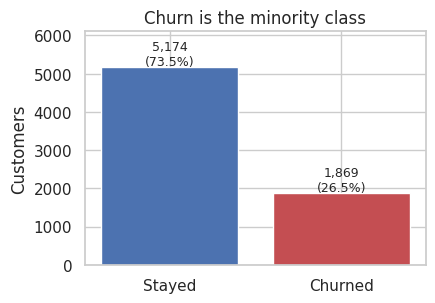

In [4]:
counts = df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.bar(["Stayed", "Churned"], counts.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 60, f"{v:,}\n({v / len(df):.1%})", ha="center", fontsize=9)
ax.set_ylabel("Customers")
ax.set_title("Churn is the minority class")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

## 4. Univariate analysis — the three numeric fields

**Observed.** `tenure` is heavily right-skewed with a large spike at 0-1
months (new customers) and a smaller one near the contract's natural
length ceiling. `MonthlyCharges` is bimodal — consistent with a
lower-cost DSL/no-internet tier and a higher-cost fibre tier, though this
notebook does not split the distribution by service to confirm that.
`TotalCharges` is, structurally, close to `tenure * MonthlyCharges`,
which Section 8's correlation check quantifies.

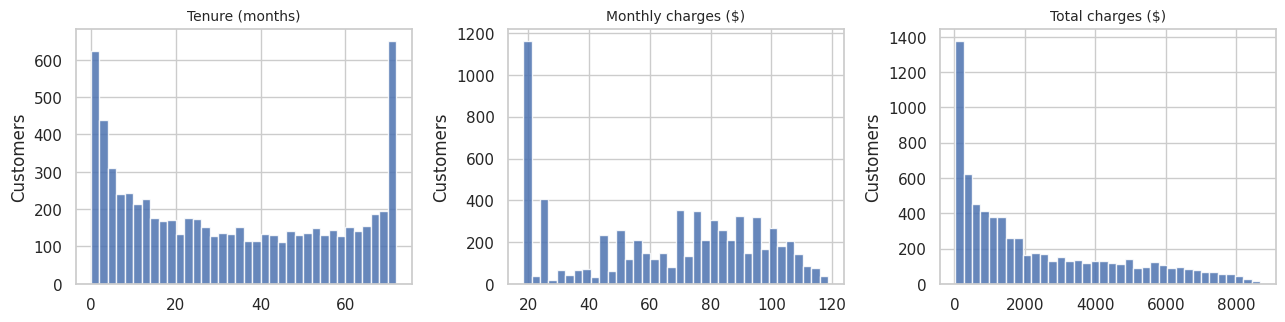

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, title in zip(
    axes,
    ["tenure", "MonthlyCharges", "TotalCharges"],
    ["Tenure (months)", "Monthly charges ($)", "Total charges ($)"],
    strict=True,
):
    ax.hist(df[col], bins=36, color="#4c72b0", alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T

## 5. Bivariate analysis — churn rate by category

**Observed.** Churn rate varies enormously across some categorical
fields and barely at all across others. The dashed line marks the overall
base rate in every panel below, so a bar's distance from it is the
category's lift (or protection) relative to an average customer.

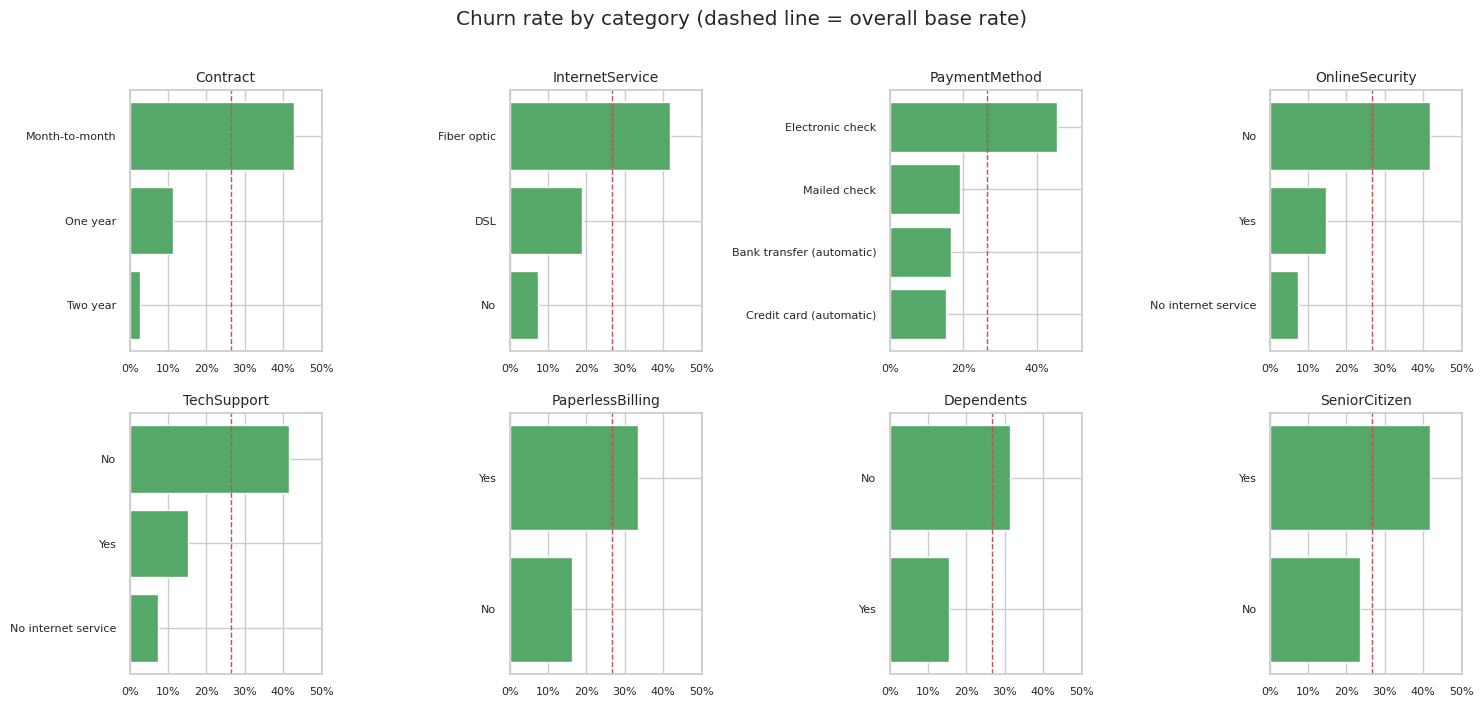

In [6]:
cat_cols = [
    "Contract", "InternetService", "PaymentMethod", "OnlineSecurity",
    "TechSupport", "PaperlessBilling", "Dependents", "SeniorCitizen",
]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
overall = df[TARGET].mean()

for ax, col in zip(axes.ravel(), cat_cols, strict=True):
    rates = df.groupby(col, observed=True)[TARGET].mean().sort_values()
    ax.barh(rates.index.astype(str), rates.values, color="#55a868")
    ax.axvline(overall, color="#c44e52", ls="--", lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, max(0.5, rates.max() * 1.15))
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.tick_params(labelsize=8)

fig.suptitle("Churn rate by category (dashed line = overall base rate)", y=1.01)
plt.tight_layout()
plt.show()

`Contract` has the widest spread of any single field here, which the next
section quantifies.

## 6. Important churn patterns

### 6.1 Contract length

**Observed.**

In [7]:
contract = (
    df.groupby("Contract", observed=True)
    .agg(customers=(TARGET, "size"), churn_rate=(TARGET, "mean"))
    .sort_values("churn_rate", ascending=False)
)
contract["lift_vs_base"] = contract["churn_rate"] / overall
contract.style.format({"churn_rate": "{:.1%}", "lift_vs_base": "{:.2f}x", "customers": "{:,}"})

,customers,churn_rate,lift_vs_base
Contract,,,
Month-to-month,"3,875",42.7%,1.61x
One year,"1,473",11.3%,0.42x
Two year,"1,695",2.8%,0.11x


Month-to-month customers churn at several times the rate of two-year
customers. **Business hypothesis** (not proven by this alone, since
committed customers may simply self-select onto longer contracts):
moving some of the month-to-month base onto annual terms would reduce
churn. A controlled offer test, not this table, is what would actually
establish that.

### 6.2 Tenure — hazard is front-loaded, not linear

**Observed.** The bins below (`_TENURE_BINS` / `_TENURE_LABELS`) are
imported directly from `src/features/engineering.py` — this is exactly
how `tenure_bucket` is computed at training and serving time, not a
notebook approximation of it.

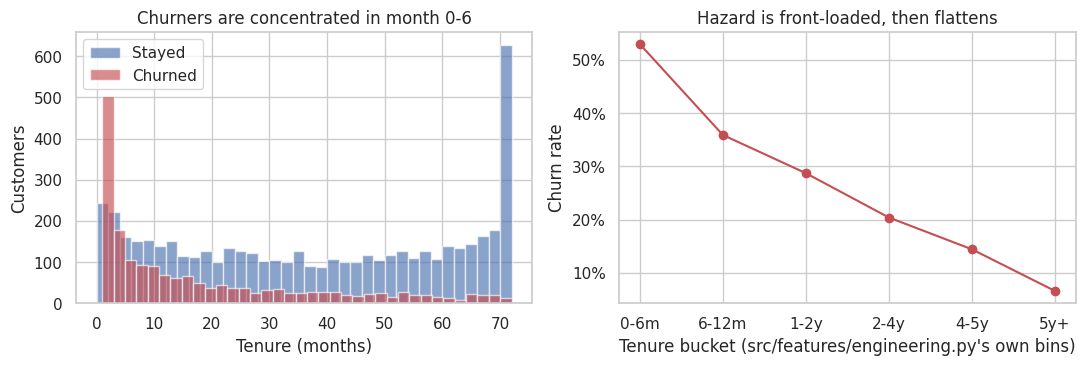

,churn_rate
tenure,
0-6m,52.9%
6-12m,35.9%
1-2y,28.7%
2-4y,20.4%
4-5y,14.4%
5y+,6.6%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for label, colour in [(0, "#4c72b0"), (1, "#c44e52")]:
    axes[0].hist(
        df.loc[df[TARGET] == label, "tenure"],
        bins=36, alpha=0.65, color=colour,
        label="Churned" if label else "Stayed",
    )
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Customers")
axes[0].set_title("Churners are concentrated in month 0-6")
axes[0].legend()

tenure_bucket_preview = pd.cut(df["tenure"], bins=_TENURE_BINS, labels=_TENURE_LABELS)
rate_by_bucket = df.groupby(tenure_bucket_preview, observed=True)[TARGET].mean()
axes[1].plot(rate_by_bucket.index.astype(str), rate_by_bucket.values, marker="o", color="#c44e52")
axes[1].set_ylabel("Churn rate")
axes[1].set_xlabel("Tenure bucket (src/features/engineering.py's own bins)")
axes[1].set_title("Hazard is front-loaded, then flattens")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()

rate_by_bucket.to_frame("churn_rate").style.format("{:.1%}")

Churn risk is highest in the first six months and falls sharply after
the first year. **Modelling decision.** This non-linearity is exactly why
`tenure_bucket` exists as a categorical feature alongside raw `tenure`: a
linear model cannot express "steep, then flat" from a single continuous
column, and even a tree model benefits from the bucket boundaries being
handed to it directly rather than re-discovered from scratch.

### 6.3 Optional services

**Observed.**

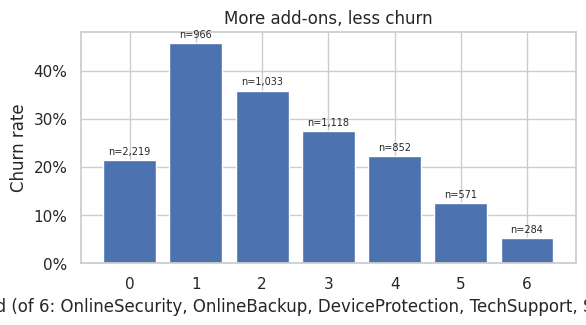

In [9]:
addon_cols_present = [c for c in ADDON_COLUMNS if c in df.columns]
addon_count_preview = (df[addon_cols_present] == "Yes").sum(axis=1)
by_addons = df.groupby(addon_count_preview, observed=True)[TARGET].agg(["size", "mean"])
by_addons.columns = ["customers", "churn_rate"]

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(by_addons.index, by_addons["churn_rate"], color="#4c72b0")
ax.set_xlabel(f"Number of add-ons held (of {len(addon_cols_present)}: {', '.join(addon_cols_present)})")
ax.set_ylabel("Churn rate")
ax.set_title("More add-ons, less churn")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for i, (n, r) in enumerate(zip(by_addons["customers"], by_addons["churn_rate"], strict=True)):
    ax.text(by_addons.index[i], r + 0.012, f"n={n:,}", ha="center", fontsize=7)
plt.tight_layout()
plt.show()

Customers holding more optional services churn less. **Business
hypothesis:** this is at least partly a commitment effect — customers who
buy more add-ons may simply be more invested to begin with — so it should
be read as a useful *predictor*, not proof that selling more add-ons
*causes* retention. `ADDON_COLUMNS` above is imported from `src.config`,
the same list `add_engineered_features` uses to build `num_addons`.

## 7. Engineered features — computed by the pipeline's own function

**Modelling decision.** The cell below calls `add_engineered_features`
directly — the same function `src/features/pipeline.py` wraps in a
`FunctionTransformer` inside the model pipeline. Every engineered column
analysed from here on is therefore *exactly* what the model sees at
training and serving time, not a hand-rebuilt approximation of it.

In [10]:
engineered = add_engineered_features(df)
new_cols = ["avg_monthly_spend", "charge_drift", "num_addons", "tenure_years", "tenure_bucket"]
engineered[new_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
avg_monthly_spend,7043.0,NaN,NaN,NaN,64.698218,30.27067,0.0,35.649,70.3,90.174158,121.4
charge_drift,7043.0,NaN,NaN,NaN,1.002308,0.051248,0.635545,0.980882,1.0,1.020801,1.450628
num_addons,7043.0,NaN,NaN,NaN,2.03791,1.847682,0.0,0.0,2.0,3.0,6.0
tenure_years,7043.0,NaN,NaN,NaN,2.697596,2.046623,0.0,0.75,2.416667,4.583333,6.0
tenure_bucket,7043,6,2-4y,1594,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 7.1 `avg_monthly_spend` and `charge_drift`

**Observed.** `avg_monthly_spend` is lifetime spend divided by months on
book, so it differs from `MonthlyCharges` whenever a customer's plan has
changed. `charge_drift` is the current charge relative to that historical
average — values above 1 mean the customer is now paying more than their
own history would suggest.

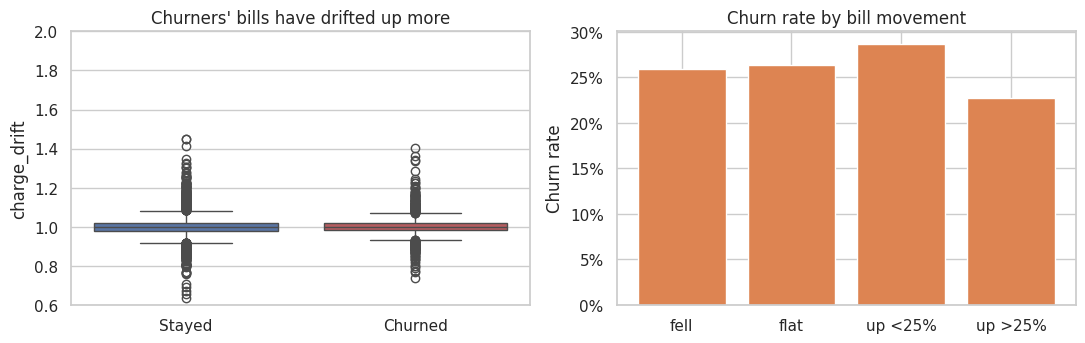

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

sns.boxplot(
    data=engineered, x=TARGET, y="charge_drift", ax=axes[0],
    hue=TARGET, palette=["#4c72b0", "#c44e52"], legend=False,
)
axes[0].set_ylim(0.6, 2.0)
axes[0].set_xticks([0, 1], ["Stayed", "Churned"])
axes[0].set_xlabel("")
axes[0].set_title("Churners' bills have drifted up more")

drift_band = pd.cut(
    engineered["charge_drift"], [0, 0.95, 1.05, 1.25, np.inf],
    labels=["fell", "flat", "up <25%", "up >25%"],
)
drift_rate = engineered.groupby(drift_band, observed=True)[TARGET].mean()
axes[1].bar(drift_rate.index.astype(str), drift_rate.values, color="#dd8452")
axes[1].set_title("Churn rate by bill movement")
axes[1].set_ylabel("Churn rate")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()

Customers whose bill has risen relative to their own history churn more
than customers on a flat or falling bill. **Business hypothesis:** a
proactive alert when a customer's charge rises sharply above their own
average could catch some of this before they leave — again, a hypothesis
a real intervention test would need to confirm, not a causal finding.

### 7.2 `num_addons` and `tenure_years`

**Observed.** `num_addons` restates the add-on pattern from Section 6.3 as
a single count rather than six separate Yes/No columns — the churn-rate
relationship is the same one already shown there, just in the form the
model actually consumes. `tenure_years` is `tenure` rescaled to years;
**modelling decision:** it exists purely so a linear model reads the same
signal on a different scale, since `LogisticRegression` is one of the
three candidate estimators `src/models/train.py` searches over and scale
matters to it in a way it does not to a tree.

## 8. Correlation / relationship analysis

**Observed.** `TotalCharges` is close to a product of `tenure` and
`MonthlyCharges`, so it is heavily collinear with both — expected, since
lifetime spend mechanically accumulates from a monthly rate over time.
**Modelling decision:** this is why the pipeline scales numeric features
and lets `LogisticRegression`'s L2 penalty absorb the redundancy, rather
than dropping a column by hand; tree-based candidates are unaffected by
collinearity in the first place.

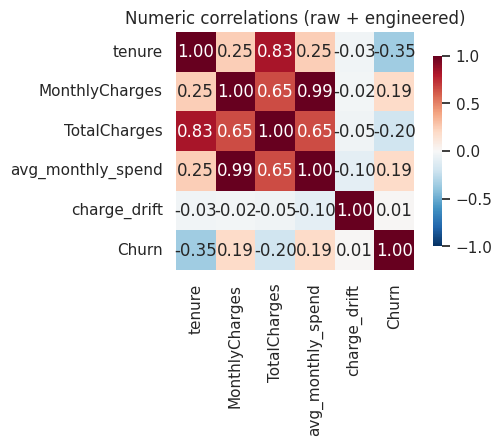

In [12]:
numeric_corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend", "charge_drift", TARGET]
corr = engineered[numeric_corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(5.8, 4.6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Numeric correlations (raw + engineered)")
plt.tight_layout()
plt.show()

`charge_drift` and `avg_monthly_spend` correlate only weakly with the raw
billing columns, which is the point of engineering them: they carry
information tenure and monthly charge alone do not already contain,
rather than duplicating it.

## 9. Business-oriented segmentation

**Business hypothesis / decision-support view.** Churn *rate* alone does
not say where a retention budget is best spent — a small high-churn
segment can matter less than a larger medium-churn one. Ranking segments
by monthly revenue at risk connects directly to the cost assumptions
`src/config.py` and `src/models/evaluate.py` actually use to pick the
model's decision threshold (Section 10): the same $-per-customer logic
applies at both the segment level here and the individual-prediction
level there.

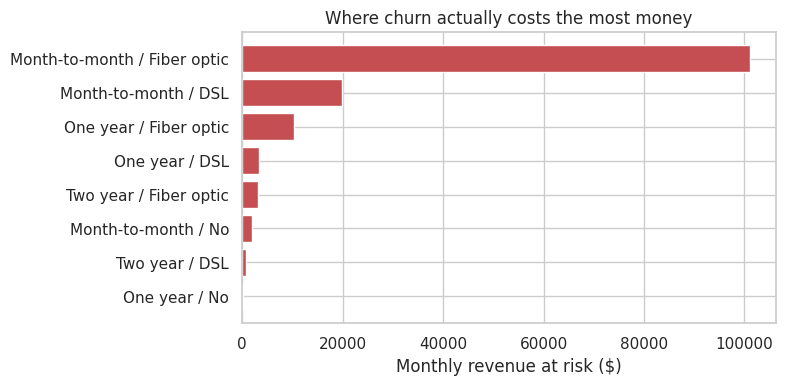

,customers,churn_rate,avg_monthly,revenue_at_risk
segment,,,,
Month-to-month / Fiber optic,"2,128",54.6%,$87.02,"$101,119"
Month-to-month / DSL,"1,223",32.2%,$50.22,"$19,786"
One year / Fiber optic,539,19.3%,$98.78,"$10,273"
One year / DSL,570,9.3%,$61.40,"$3,254"
Two year / Fiber optic,429,7.2%,$104.57,"$3,242"
Month-to-month / No,524,18.9%,$20.41,"$2,021"
Two year / DSL,628,1.9%,$70.46,$846
One year / No,364,2.5%,$20.82,$187


In [13]:
segments = (
    df.assign(segment=df["Contract"] + " / " + df["InternetService"])
    .groupby("segment", observed=True)
    .agg(customers=(TARGET, "size"), churn_rate=(TARGET, "mean"), avg_monthly=("MonthlyCharges", "mean"))
)
segments["revenue_at_risk"] = segments["customers"] * segments["churn_rate"] * segments["avg_monthly"]
segments = segments.sort_values("revenue_at_risk", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
top = segments.head(8).iloc[::-1]
ax.barh(top.index, top["revenue_at_risk"], color="#c44e52")
ax.set_xlabel("Monthly revenue at risk ($)")
ax.set_title("Where churn actually costs the most money")
plt.tight_layout()
plt.show()

segments.head(8).style.format({
    "customers": "{:,}", "churn_rate": "{:.1%}",
    "avg_monthly": "${:.2f}", "revenue_at_risk": "${:,.0f}",
})

Month-to-month, fiber-optic customers are consistently the largest block
of revenue at risk — the same segment Section 6.1 and the categorical
panel in Section 5 already flagged from two different angles.

## 10. Class imbalance and the choice of evaluation metric, revisited

**Modelling decision, with the actual numbers.** Loading the trained
model's own metadata rather than retyping its metrics by hand, so this
section cannot drift from what was actually trained.

In [14]:
if not MODEL_PATH.exists():
    print(f"{MODEL_PATH} not found -- run `python -m src.models.train` to produce it.")
    metadata = None
else:
    metadata = json.loads((MODEL_PATH.parent / "model_metadata.json").read_text())
    tm = metadata["test_metrics"]
    print(f"Selected model family:   {metadata['model_family']}")
    print(f"Decision threshold:       {metadata['threshold']:.2f}  (not 0.5 -- see below)")
    print(f"Cross-validated PR-AUC:   {metadata['cv_pr_auc']:.4f}")
    print(f"Test ROC-AUC / PR-AUC:    {tm['roc_auc']:.4f} / {tm['pr_auc']:.4f}")
    print(f"Test accuracy:            {tm['accuracy']:.4f}  (reported, not used to select the model)")
    print(f"Test precision / recall:  {tm['precision']:.3f} / {tm['recall']:.3f}")

Selected model family:   random_forest
Decision threshold:       0.58  (not 0.5 -- see below)
Cross-validated PR-AUC:   0.6641
Test ROC-AUC / PR-AUC:    0.8466 / 0.6652
Test accuracy:            0.7835  (reported, not used to select the model)
Test precision / recall:  0.574 / 0.714


**Why not accuracy.** With churn at roughly a quarter of the base, a
model that never predicts churn scores close to 74% accuracy while being
useless — the number above is only meaningfully better than that baseline
because of what the confusion matrix underneath it looks like, not
because accuracy alone is impressive. `src/models/train.py` selects
between model families on cross-validated **PR-AUC**, and reports
ROC-AUC and Brier score alongside it; accuracy is computed only *after*
a family and threshold are already chosen, as one more descriptive
statistic, never as the selection criterion.

**Why the threshold is not 0.5.** `src/models/evaluate.py` chooses the
decision threshold by maximising *expected campaign value* — contacting a
customer costs a fixed amount whether or not they were going to leave,
and a saved customer is worth a fixed amount, and those two numbers
together (declared in `src/config.py`, reproduced below rather than
retyped) determine which threshold actually makes money, which is not
generally 0.5 or the F1-maximising cut-off.

In [15]:
if metadata is not None:
    costs = metadata["cost_assumptions"]
    print(f"Retention contact cost:        ${costs['retention_offer_cost']:.0f}")
    print(f"Value of a saved customer:     ${costs['customer_lifetime_value']:.0f}")
    print(f"Assumed offer acceptance rate: {costs['offer_acceptance_rate']:.0%}")
    print(f"\n-> chosen threshold: {metadata['threshold']:.2f}")

Retention contact cost:        $60
Value of a saved customer:     $500
Assumed offer acceptance rate: 35%

-> chosen threshold: 0.58


**Limitation.** These three numbers are declared assumptions, not
measured facts — a real deployment would source them from the retention
team and re-run `choose_threshold` whenever they change, rather than
treating 0.58 as permanent.

## 11. Key findings & connection to modelling

**Modelling decision, checked against evidence.** The chart below is the
trained model's own feature-importance ranking (`top_drivers` in
`model_metadata.json`), not a notebook opinion about what should matter —
this is the strongest evidence in this notebook that the EDA above and
the deployed model actually agree with each other.

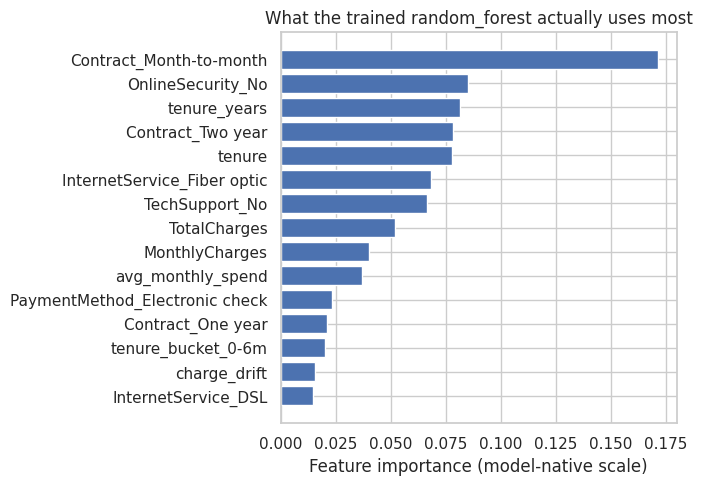

In [16]:
if metadata is not None and metadata.get("top_drivers"):
    drivers = pd.Series(metadata["top_drivers"]).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(drivers.index, drivers.values, color="#4c72b0")
    ax.set_xlabel("Feature importance (model-native scale)")
    ax.set_title(f"What the trained {metadata['model_family']} actually uses most")
    plt.tight_layout()
    plt.show()

| EDA finding (this notebook) | What it motivated in `src/` |
|---|---|
| Churn hazard is front-loaded, not linear in tenure (§6.2) | `tenure_bucket`, and it appears among the model's top drivers above |
| Contract length has the widest churn spread of any category (§5, §6.1) | Contract stays a raw categorical; its levels dominate the top-driver ranking |
| More add-ons associate with lower churn (§6.3) | `num_addons`, built from `ADDON_COLUMNS` in `src.config` |
| Bill increases associate with higher churn (§7.1) | `charge_drift` |
| Plan changes hide inside `TotalCharges` alone (§7.1) | `avg_monthly_spend` |
| ~26% positive class (§3) | PR-AUC as the model-selection metric, not accuracy |
| Retention economics are asymmetric, not symmetric (§9, §10) | Cost-based threshold search in `src/models/evaluate.py`, landing on 0.58 |

Every row on the right is something that already exists in `src/` before
this notebook was written — nothing above is a recommendation to change
the model. Where this notebook's own read of the data agrees with the
model's top drivers (tenure, contract, and the engineered spend/drift
features all appear on both sides), that agreement is the actual point:
it is evidence the feature engineering is capturing signal the raw
columns alone left on the table, not a coincidence to admire.

## 12. Limitations

- **Observational, not experimental.** Every relationship above is an
  association in historical data. None of the "business hypothesis"
  statements in this notebook are causal claims, and none should be acted
  on without a controlled test.
- **No temporal information.** The dataset is a single snapshot with no
  timestamps, so there is no way to build a time-based train/test split
  here or in the pipeline — `src/data/preprocess.py` uses a random
  stratified split, which is optimistic relative to how the model would
  actually be validated if the business deployed it and re-trained it
  over time.
- **Cost assumptions are illustrative.** The $60 / $500 / 35% figures
  behind the decision threshold (§10) are stated, reasonable-looking
  placeholders, not sourced from a real retention team.
- **Single dataset, single company.** These patterns describe this one
  telecom's historical customers. They are not claimed to generalise to a
  different provider, market, or time period.
- **Segment-level views can obscure smaller but important groups.** The
  revenue-at-risk ranking in §9 favours large segments by construction; a
  small segment with very high risk can still be worth targeting even if
  it never appears near the top of that list.